## Access Station Lucinda Jetty Dalec Derived Product (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_dalec_derived_product data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_dalec_derived_product.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_dalec_derived_product"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 477ms
Checked 155 packages in 2ms


✅ Local version 0.3.15 is up to date (remote: 0.3.15)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4335: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 1.89 s, sys: 203 ms, total: 2.09 s
Wall time: 3.66 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	WAVELENGTH = 596 ;
	TIME = 2920197 ;

variables:
	float64 LATITUDE() ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE() ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:units = degrees_east ;
		LONGITUDE:valid_max = 180.0 ;
		LONGITUDE:valid_min = -180.0 ;
	float64 Rrs(WAVELENGTH, TIME) ;
		Rrs:ancillary_variables = Rrs_xflags relaz sza windspeed ;
		Rrs:cell_method = LATITUDE: LONGITUDE: TIME: point ;
		Rrs:intercept = 0.0 ;
		Rrs:long_name = Remote Sensing Reflectance ;
		Rrs:slope = 1.0 ;
		Rrs:units = sr^-1 ;
		Rrs:varname = Rrs ;
	int32 Rrs_xflags(WAVELENGTH, TIME) ;
		Rrs_xflags:anc

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2016-05-26 23:15:53.338073088'),
 Timestamp('2018-12-13 00:11:32.346074112'))

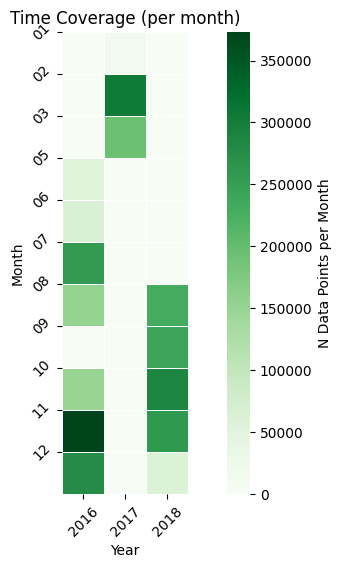

In [7]:
aodn_dataset.plot_time_coverage()

## Load Rrs Data

Access the Zarr store containing DALEC-derived Remote Sensing Reflectance (Rrs).
Remote Sensing Reflectance is calculated as:

> **Rrs(λ) = (Lu(λ) − ρ(λ) · Lsky(λ)) / Ed(λ)**

where **ρ** is the Fresnel reflectance factor for the air–sea interface,
estimated using the Mobley (1999) lookup table with wind speed correction.

This FV02 product has been quality-controlled and spans ~380–800 nm at ~0.5 nm resolution.
Rrs at Lucinda Jetty exhibits a characteristic **green-peaked, turbid coastal signature**
driven by sediment resuspension, CDOM loading, and phytoplankton absorption.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

xds = aodn_dataset.zarr_store

time_vals = xds['TIME'].values
t_min = pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
t_max = pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')
wl    = xds['WAVELENGTH'].values

print(f'Dataset      : {xds.dims["TIME"]:,} time steps  ({t_min}  →  {t_max})')
print(f'Wavelengths  : {wl.min():.1f}–{wl.max():.1f} nm  ({len(wl)} bands)')

#print(f'Rrs range    : {float(xds["Rrs"].min()):.4f}–{float(xds["Rrs"].max()):.4f} sr⁻¹')
print()
#print(xds['Rrs'])

Dataset      : 2,920,197 time steps  (2016-05-26  →  2018-12-13)
Wavelengths  : 405.0–1000.0 nm  (596 bands)



## Rrs Hyperspectral Signatures

Full Rrs spectra at selected dates (daily median), with standard ocean-colour
satellite band centres overlaid.

- **MODIS Aqua** (blue dashed): primary validation satellite for LJCO
- **Sentinel-3 OLCI** (orange dotted): operational ocean-colour monitoring
- **PACE OCI** (green): next-generation hyperspectral ocean colour

A green-peaked, low-blue Rrs is typical of turbid coastal water at Lucinda Jetty,
reflecting high sediment scattering and CDOM absorption that suppress the blue signal.
The shape shifts toward higher blue-to-green ratios during the dry season (JJA)
when river discharge and wind-driven resuspension are at their minimum.

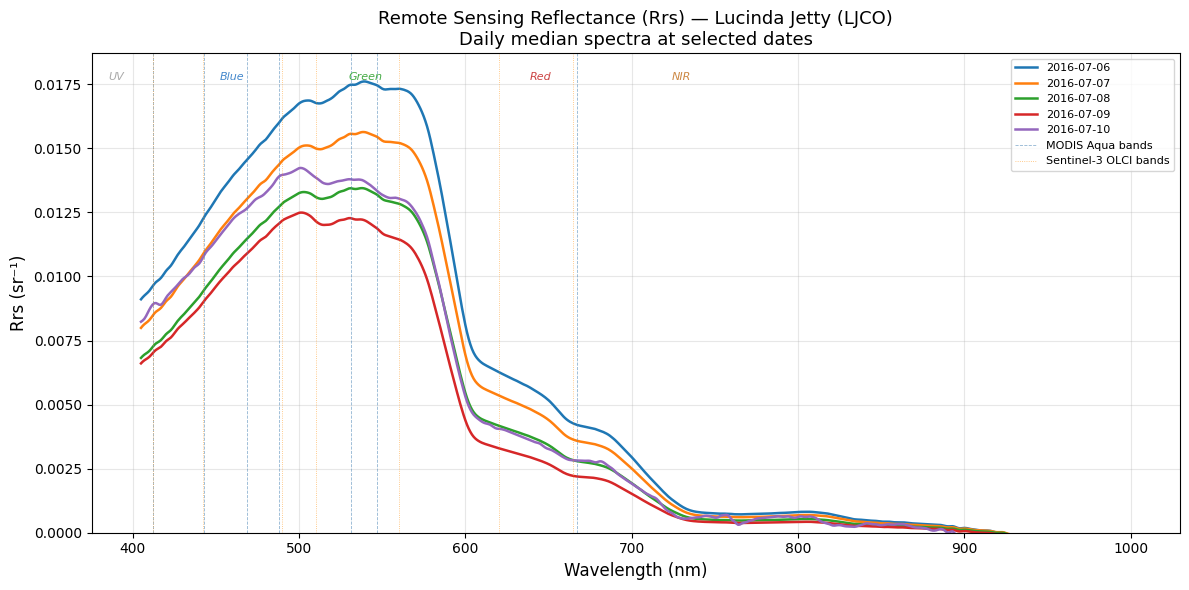

In [9]:
DATE_START = '2016-07-01'
DATE_END   = '2016-07-10'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl = xds['WAVELENGTH'].values
rrs_da    = xds['Rrs'].sel(TIME=slice(DATE_START, DATE_END))
rrs_daily = rrs_da.resample(TIME='1D').median('TIME').astype(float)

# Pick 6 evenly-spaced dates with valid data
good_times = rrs_daily.TIME.values[
    np.where(~np.all(np.isnan(rrs_daily.values), axis=0))[0]
]
n_show    = min(6, len(good_times))
pick_idx  = np.linspace(0, len(good_times) - 1, n_show, dtype=int)
sample_times = good_times[pick_idx]

MODIS_BANDS = [412, 443, 469, 488, 531, 547, 667]
OLCI_BANDS  = [412.5, 442.5, 490, 510, 560, 620, 665]

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap('tab10')

for i, t in enumerate(sample_times):
    spec  = rrs_daily.sel(TIME=t, method='nearest').values
    label = pd.Timestamp(t).strftime('%Y-%m-%d')
    ax.plot(wl, spec, color=cmap(i), lw=1.8, label=label)

drawn = set()
for b in MODIS_BANDS:
    lbl = 'MODIS Aqua bands' if 'MODIS' not in drawn else '_'
    drawn.add('MODIS')
    ax.axvline(b, color='steelblue', lw=0.6, ls='--', alpha=0.6, label=lbl)
for b in OLCI_BANDS:
    lbl = 'Sentinel-3 OLCI bands' if 'OLCI' not in drawn else '_'
    drawn.add('OLCI')
    ax.axvline(b, color='darkorange', lw=0.6, ls=':', alpha=0.6, label=lbl)

for xpos, txt, col in [(390,'UV','#aaa'),(460,'Blue','#4488cc'),
                        (540,'Green','#44aa44'),(645,'Red','#cc4444'),
                        (730,'NIR','#cc8844')]:
    ylim = ax.get_ylim()
    ymax = ylim[1] if ylim[1] > 0 else 0.02
    ax.text(xpos, ymax*0.96, txt, ha='center', va='top', fontsize=8, color=col, style='italic')

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Rrs (sr⁻¹)', fontsize=12)
ax.set_title(
    'Remote Sensing Reflectance (Rrs) — Lucinda Jetty (LJCO)\n'
    'Daily median spectra at selected dates',
    fontsize=13,
)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rrs Hovmöller Diagram

Wavelength–time heatmap of daily-median Rrs.
This visualisation reveals the **seasonal optical cycle** at Lucinda Jetty:

- **Wet season (DJF)**: elevated Rrs at green–red wavelengths (sediment, CDOM)
- **Dry season (JJA)**: relatively higher blue-band Rrs, cleaner spectral shape
- Gaps indicate days with no valid observations (cloud, adverse geometry)

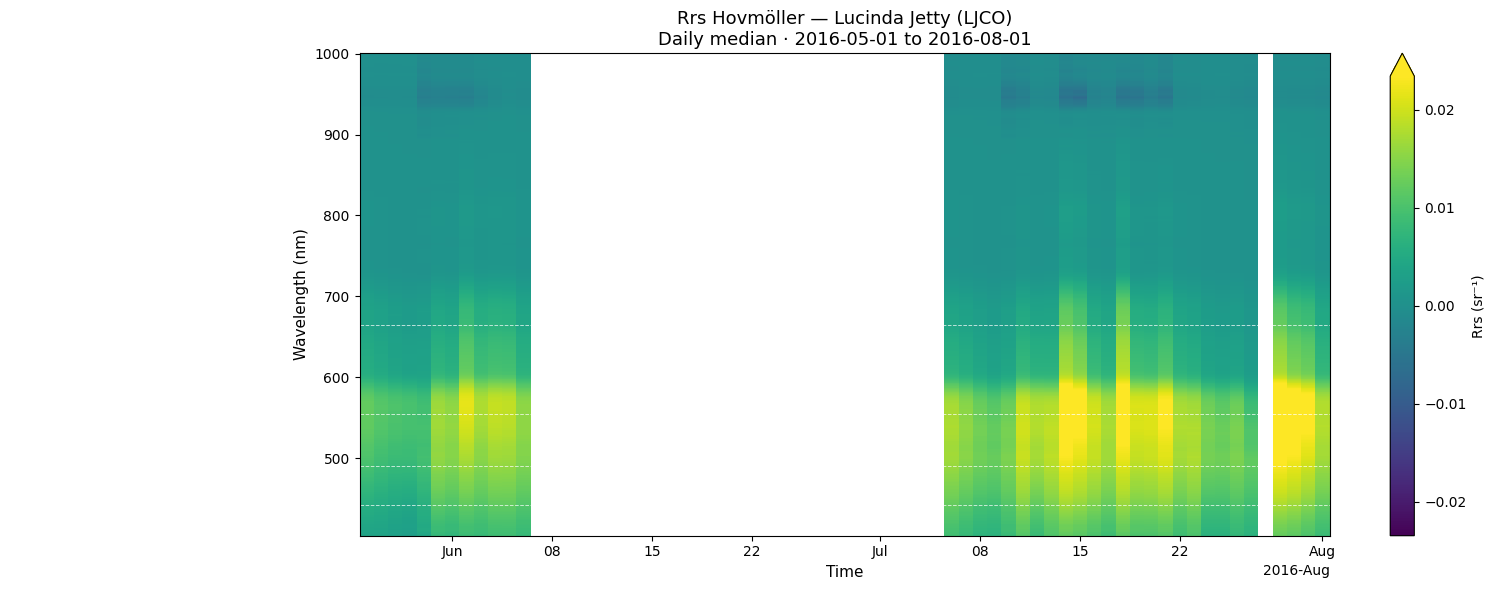

In [10]:
DATE_START = '2016-05-01'
DATE_END   = '2016-08-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

rrs_daily = (
    xds['Rrs']
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME='1D').median('TIME')
    .astype(float)
)

fig, ax = plt.subplots(figsize=(16, 6))
rrs_daily.plot(
    x='TIME', y='WAVELENGTH',
    ax=ax, robust=True,
    cmap='viridis',
    cbar_kwargs={'label': 'Rrs (sr⁻¹)'},
)
ax.set_title(
    'Rrs Hovmöller — Lucinda Jetty (LJCO)\n'
    f'Daily median · {DATE_START} to {DATE_END}',
    fontsize=13,
)
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Wavelength (nm)', fontsize=11)

for wl_mark, lbl in [(443,'443 nm'),(490,'490 nm'),(555,'555 nm'),(665,'665 nm')]:
    ax.axhline(wl_mark, color='white', lw=0.7, ls='--', alpha=0.7)
    ax.text(pd.Timestamp(DATE_START), wl_mark + 4, lbl,
            color='white', fontsize=7, va='bottom')

plt.tight_layout()
plt.show()

## Rrs Time Series at Key Ocean-Colour Wavelengths

Daily-median Rrs at four wavelengths coinciding with standard satellite ocean-colour bands.
These wavelengths are routinely used to retrieve chlorophyll-a, turbidity, and CDOM:

| Wavelength | Primary use |
|---|---|
| **443 nm** | Phytoplankton / chlorophyll-a absorption maximum |
| **490 nm** | CDOM and detrital matter absorption |
| **555 nm** | Reference "green" band, sediment proxy |
| **665 nm** | Chlorophyll-a red absorption, turbidity |

The annual cycle is dominated by wet-season (DJF) increases at 555–665 nm
due to river-borne sediment and CDOM, with the blue bands (443, 490 nm) suppressed.

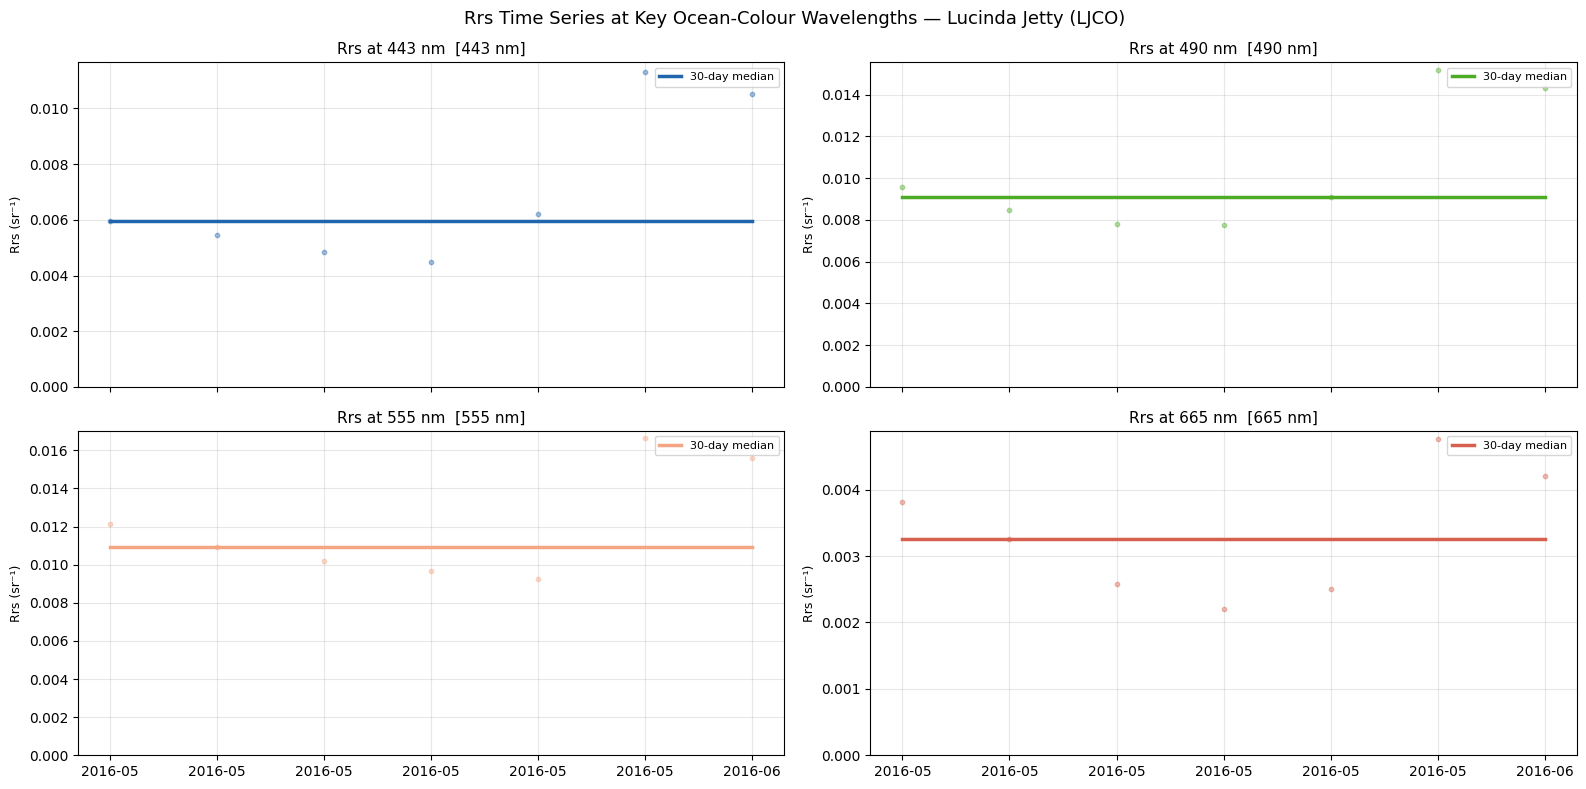

In [11]:
DATE_START = '2016-05-01'
DATE_END   = '2016-06-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl_arr = xds['WAVELENGTH'].values
rrs_daily = (
    xds['Rrs']
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME='1D').median('TIME')
    .astype(float)
)
t_d = pd.to_datetime(rrs_daily.TIME.values)

KEY_WL = {'443 nm': 443, '490 nm': 490, '555 nm': 555, '665 nm': 665}
COLORS = {'443 nm': '#2166ac', '490 nm': '#4dac26', '555 nm': '#f4a582', '665 nm': '#d6604d'}

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, (label, target_wl) in zip(axes, KEY_WL.items()):
    idx  = int(np.argmin(np.abs(wl_arr - target_wl)))
    ts   = rrs_daily.isel(WAVELENGTH=idx).values
    color = COLORS[label]
    valid = ~np.isnan(ts)
    ax.scatter(t_d[valid], ts[valid], s=10, alpha=0.4, color=color, zorder=2)
    # 30-day rolling median
    roll = pd.Series(ts, index=t_d).rolling('30D', center=True, min_periods=5).median()
    ax.plot(roll.index, roll.values, color=color, lw=2.5, label='30-day median')
    ax.set_title(f'Rrs at {wl_arr[idx]:.0f} nm  [{label}]', fontsize=11)
    ax.set_ylabel('Rrs (sr⁻¹)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle(
    'Rrs Time Series at Key Ocean-Colour Wavelengths — Lucinda Jetty (LJCO)',
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Ocean-Colour Band Ratios

Band ratios computed from daily-median Rrs:

| Ratio | Proxy | Typical range at LJCO |
|---|---|---|
| **Rrs(490) / Rrs(555)** | Turbidity / CDOM index | Higher = cleaner water |
| **Rrs(443) / Rrs(555)** | Phytoplankton / CDOM absorption | Lower = more absorption |

These ratios form the basis of empirical chlorophyll-a and turbidity algorithms
(e.g. OC3, OC4). At turbid LJCO, Rrs(490)/Rrs(555) < 1 is common during
the wet season, indicating strong sediment + CDOM dominance.

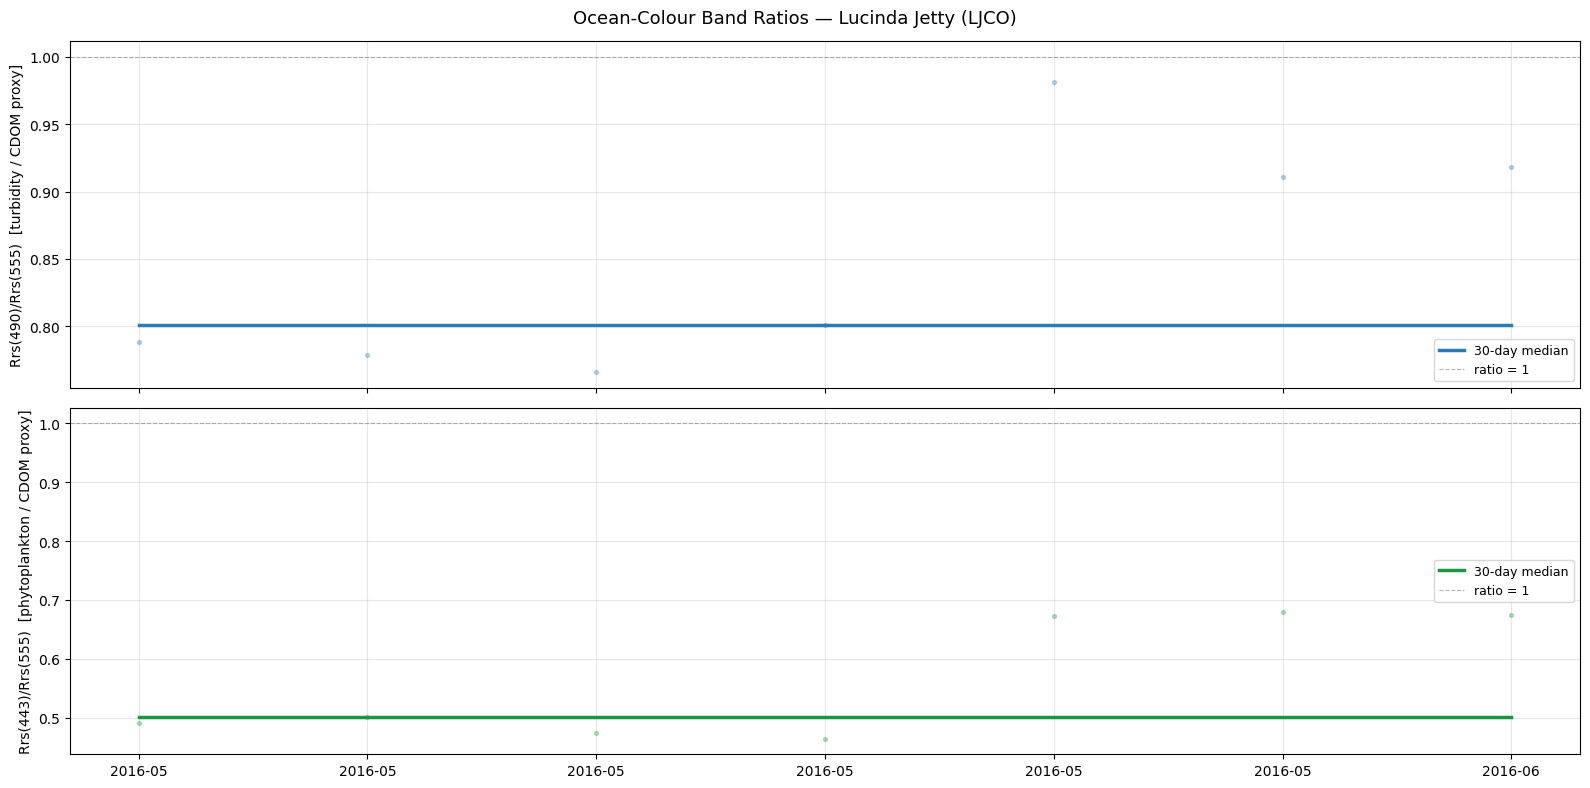

In [12]:
DATE_START = '2016-05-01'
DATE_END   = '2016-06-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl_arr = xds['WAVELENGTH'].values
rrs_daily = (
    xds['Rrs']
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME='1D').median('TIME')
    .astype(float)
)
t_d = pd.to_datetime(rrs_daily.TIME.values)

def rrs_at(wl_target):
    idx = int(np.argmin(np.abs(wl_arr - wl_target)))
    return rrs_daily.isel(WAVELENGTH=idx).values

rrs_443 = rrs_at(443); rrs_490 = rrs_at(490); rrs_555 = rrs_at(555)

r490_555 = np.where(rrs_555 > 0, rrs_490 / rrs_555, np.nan)
r443_555 = np.where(rrs_555 > 0, rrs_443 / rrs_555, np.nan)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, ratio, label, color in [
    (ax1, r490_555, 'Rrs(490)/Rrs(555)  [turbidity / CDOM proxy]',   '#2c7bb6'),
    (ax2, r443_555, 'Rrs(443)/Rrs(555)  [phytoplankton / CDOM proxy]','#1a9641'),
]:
    valid = ~np.isnan(ratio)
    ax.scatter(t_d[valid], ratio[valid], s=8, alpha=0.3, color=color, zorder=2)
    roll = pd.Series(ratio, index=t_d).rolling('30D', center=True, min_periods=5).median()
    ax.plot(roll.index, roll.values, color=color, lw=2.5, label='30-day median')
    ax.set_ylabel(label, fontsize=10)
    ax.axhline(1.0, color='grey', lw=0.8, ls='--', alpha=0.6, label='ratio = 1')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle(
    'Ocean-Colour Band Ratios — Lucinda Jetty (LJCO)',
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Seasonal Mean Rrs Spectra

Mean (±1σ) Rrs spectra grouped by austral season.
The strong seasonal contrast at LJCO is driven by the North Queensland wet/dry cycle:

- **DJF** (Dec–Feb) — wet season: highest turbidity and CDOM from river runoff into the GBR lagoon
- **MAM** (Mar–May) — transition: declining turbidity as monsoon retreats
- **JJA** (Jun–Aug) — dry season: clearest water, lowest Rrs overall
- **SON** (Sep–Nov) — pre-wet: building primary production, trade wind mixing

The crossover point where green Rrs exceeds blue Rrs shifts with season,
providing a proxy for the optical water type.

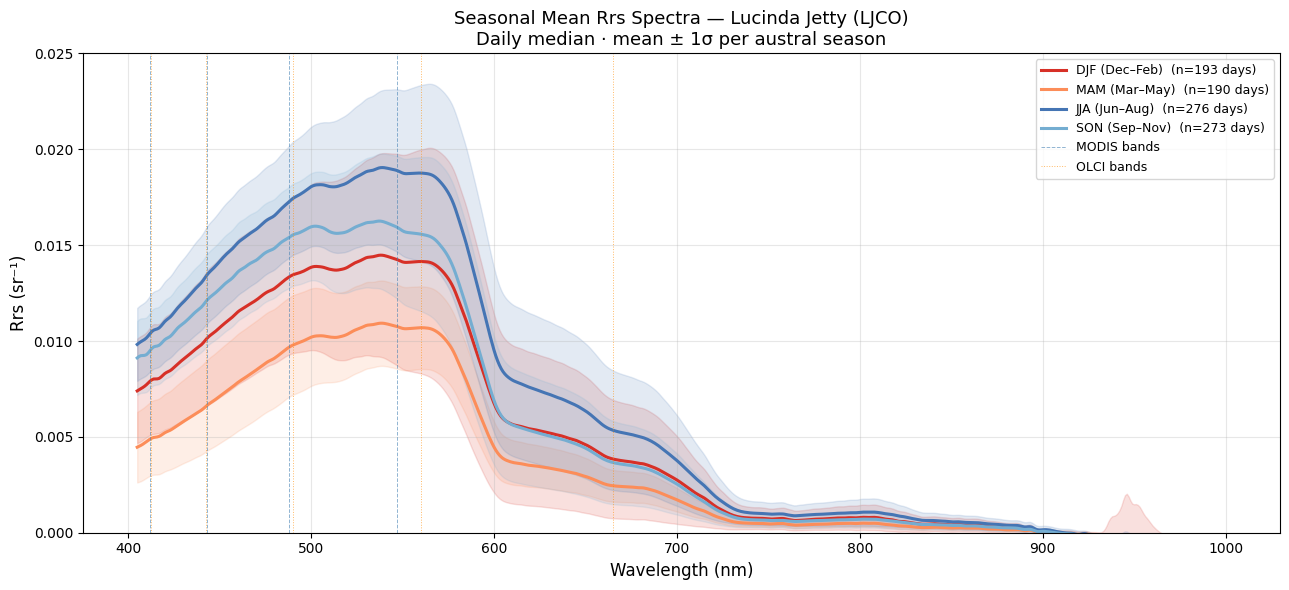

In [13]:
DATE_START = ''
DATE_END   = ''
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

wl_arr = xds['WAVELENGTH'].values
rrs_daily = (
    xds['Rrs']
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME='1D').median('TIME')
    .astype(float)
)
months = pd.to_datetime(rrs_daily.TIME.values).month
rrs_np = rrs_daily.values  # (WAVELENGTH, TIME)

seasons = {
    'DJF (Dec–Feb)': ([12, 1, 2],  '#d73027'),
    'MAM (Mar–May)': ([3, 4, 5],   '#fc8d59'),
    'JJA (Jun–Aug)': ([6, 7, 8],   '#4575b4'),
    'SON (Sep–Nov)': ([9, 10, 11], '#74add1'),
}

MODIS_BANDS = [412, 443, 469, 488, 531, 547, 667]
OLCI_BANDS  = [412.5, 442.5, 490, 510, 560, 620, 665]

fig, ax = plt.subplots(figsize=(13, 6))
drawn_labels = set()

for season, (month_list, color) in seasons.items():
    mask = np.isin(months, month_list)
    if mask.sum() == 0:
        continue
    s_data = rrs_np[:, mask]
    mean_s = np.nanmean(s_data, axis=1)
    std_s  = np.nanstd(s_data,  axis=1)
    n_obs  = mask.sum()
    ax.plot(wl_arr, mean_s, color=color, lw=2.2, label=f'{season}  (n={n_obs:,} days)')
    ax.fill_between(wl_arr, mean_s - std_s, mean_s + std_s, color=color, alpha=0.15)

for wl_b, sat, col in [(412,'MODIS','steelblue'),(443,'MODIS','steelblue'),
                        (488,'MODIS','steelblue'),(547,'MODIS','steelblue'),
                        (412.5,'OLCI','darkorange'),(442.5,'OLCI','darkorange'),
                        (490,'OLCI','darkorange'),(560,'OLCI','darkorange'),
                        (665,'OLCI','darkorange')]:
    lbl = f'{sat} bands' if (sat, col) not in drawn_labels else '_'
    drawn_labels.add((sat, col))
    ls = '--' if sat == 'MODIS' else ':'
    ax.axvline(wl_b, color=col, lw=0.7, ls=ls, alpha=0.6, label=lbl)

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Rrs (sr⁻¹)', fontsize=12)
ax.set_ylim(bottom=0)
ax.set_title(
    'Seasonal Mean Rrs Spectra — Lucinda Jetty (LJCO)\n'
    'Daily median · mean ± 1σ per austral season',
    fontsize=13,
)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sky Glint Correction Factor (ρ) and Wind Speed

The Fresnel sea-surface reflectance factor **ρ** determines how much sky radiance
is subtracted in the Rrs retrieval:

> **Rrs = (Lu − ρ · Lsky) / Ed**

ρ depends on wind speed (sea surface roughness) and solar/viewing geometry.
At LJCO, typical ρ values fall in the range 0.02–0.08.

**Left panel**: scatter plot of ρ vs wind speed (colour-coded by solar zenith angle).
A positive correlation is expected from the Mobley (1999) lookup table:
higher winds → rougher sea surface → larger effective ρ.

**Right panel**: ρ time series (daily median) overlaid with wind speed.
Elevated ρ may indicate foam/whitecap contamination or adverse viewing geometry.

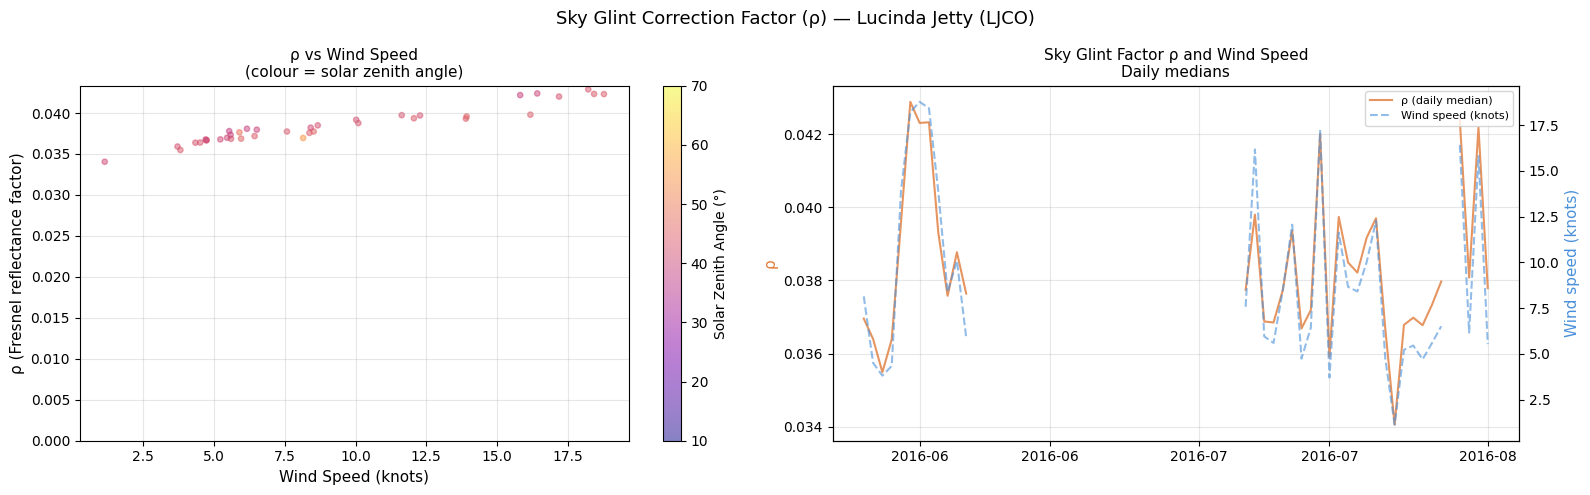

In [14]:
DATE_START = '2016-05-01'
DATE_END   = '2016-08-01'
time_vals = xds['TIME'].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime('%Y-%m-%d')
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime('%Y-%m-%d')

t_slice = slice(DATE_START, DATE_END)

# Daily medians (rho is a scalar per observation, not wavelength-resolved in this dataset)
rho_da  = xds['rho'].sel(TIME=t_slice)
ws_da   = xds['windspeed'].sel(TIME=t_slice)
sza_da  = xds['sza'].sel(TIME=t_slice)

if 'WAVELENGTH' in rho_da.dims:
    rho_da = rho_da.isel(WAVELENGTH=0, drop=True)
if 'WAVELENGTH' in ws_da.dims:
    ws_da = ws_da.isel(WAVELENGTH=0, drop=True)
if 'WAVELENGTH' in sza_da.dims:
    sza_da = sza_da.isel(WAVELENGTH=0, drop=True)
rho_d = pd.Series(rho_da.values.astype(float), index=pd.to_datetime(rho_da.TIME.values)).resample('1D').median()
ws_d  = pd.Series(ws_da.values.astype(float),  index=pd.to_datetime(ws_da.TIME.values)).resample('1D').median()
sza_d = pd.Series(sza_da.values.astype(float), index=pd.to_datetime(sza_da.TIME.values)).resample('1D').median()

# Align on common index
idx_common = rho_d.index.intersection(ws_d.index).intersection(sza_d.index)
rho_v = rho_d.loc[idx_common].values
ws_v  = ws_d.loc[idx_common].values
sza_v = sza_d.loc[idx_common].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: rho vs wind speed coloured by sza
valid = ~(np.isnan(rho_v) | np.isnan(ws_v) | np.isnan(sza_v))
sc = ax1.scatter(ws_v[valid], rho_v[valid], c=sza_v[valid], cmap='plasma',
                 s=15, alpha=0.5, vmin=10, vmax=70)
plt.colorbar(sc, ax=ax1, label='Solar Zenith Angle (°)')
ax1.set_xlabel('Wind Speed (knots)', fontsize=11)
ax1.set_ylabel('ρ (Fresnel reflectance factor)', fontsize=11)
ax1.set_title('ρ vs Wind Speed\n(colour = solar zenith angle)', fontsize=11)
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# Time series: rho and wind speed
ax2b = ax2.twinx()
ax2.plot(rho_d.index, rho_d.values, color='#e07b39', lw=1.5, label='ρ (daily median)', alpha=0.8)
ax2b.plot(ws_d.index, ws_d.values,  color='#4a90d9', lw=1.5, label='Wind speed (knots)', alpha=0.6, ls='--')
ax2.set_ylabel('ρ', fontsize=11, color='#e07b39')
ax2b.set_ylabel('Wind speed (knots)', fontsize=11, color='#4a90d9')
ax2.set_title('Sky Glint Factor ρ and Wind Speed\nDaily medians', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

fig.suptitle(
    'Sky Glint Correction Factor (ρ) — Lucinda Jetty (LJCO)',
    fontsize=13,
)
plt.tight_layout()
plt.show()